# 02 — Background noise: trading that has nothing to do with our pool

> **Reminder before you run this:** notebooks are meant to be run top to bottom, in
> order (in Jupyter: "Run All" or "Restart Kernel and Run All Cells"). Some later cells
> use results computed by earlier ones. If you run a cell on its own without running the
> ones above it first, you may see a `NameError` — that's not a bug in the logic, just a
> missing step. Running the whole notebook in order (as we do before every commit) always
> works.

Real markets never sit still, and not every trade that touches our pool is trying to
correct its skew. Some trading is just ordinary background activity — people buying and
selling for their own reasons, with no idea (and no reason to care) whether our pool is
currently on-target or not. `ADR-0008` calls this "organic flow," and it's one of the two
kinds of trading our simulation needs to model realistically (the other kind, the
*corrective* trading that actually pulls the pool back toward target, is notebook 03).

This notebook builds and checks that background-noise model
(`aqua_sim.flows.maybe_exogenous_trade`): trades arrive at random times, in a random
direction, at a random size. We check four things: trades arrive about as often as we
configured, the direction really is a coin flip (no hidden bias), the sizes follow the
distribution we asked for, and the pool never ends up in a broken/impossible state no
matter how these random trades land.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from aqua_sim.curve import CurveState
from aqua_sim.flows import ExogenousFlowConfig, maybe_exogenous_trade

DT_YEARS = 1 / (365 * 24 * 60)  # 1-minute steps

## 1. Trades show up about as often as we told the model to

We configure "one background trade per hour, on average" and let the simulation run for
about 139 days (200,000 one-minute steps). We should see roughly `24 trades/day × 139
days ≈ 137` trades — not exactly 137 (randomness means it'll be a bit more or less), but
close enough that we can tell the arrival logic is working and not, say, firing ten times
too often or basically never.

In [2]:
rng = np.random.default_rng(0)
config = ExogenousFlowConfig(arrival_rate_per_year=365 * 24, mean_size_fraction=0.01)
state = CurveState(balance_in=10_000, balance_out=10_000, weight_in=0.5, weight_out=0.5)

n_steps = 200_000
n_trades = 0
trade_sizes = []

for _ in range(n_steps):
    state, amount_in, happened = maybe_exogenous_trade(state, DT_YEARS, config, rng)
    if happened:
        n_trades += 1
        trade_sizes.append(amount_in)
    assert state.balance_in > 0 and state.balance_out > 0, "pool state must stay valid throughout"

expected_trades = config.arrival_rate_per_year * DT_YEARS * n_steps
assert abs(n_trades - expected_trades) < 4 * np.sqrt(expected_trades), (
    f"{n_trades} trades far outside Poisson noise band around expected {expected_trades:.1f}"
)
print(f"{n_trades} trades fired (expected ~{expected_trades:.1f}); pool state stayed valid throughout")

3271 trades fired (expected ~3333.3); pool state stayed valid throughout


## 2. No hidden bias in which direction background trades go

Every background trade is a coin flip: buy or sell, 50/50, with no preference either way.
But here's a subtlety worth explaining before we check it: because each trade moves the
pool by a *percentage* of its current balance (not a fixed amount), the balance behaves
like a stack of compounding coin flips — even with zero bias, one single random walk can
still wander pretty far from where it started, purely by chance (the same way a fair coin
flipped many times in a row can still land heads far more than tails in any one run).

So checking "did this one walk stay close to where it started?" would be the wrong test —
it's expected NOT to, and asserting otherwise would itself be a mistake, not a real check.
The right test is: run the walk many times, independently, and check that the *average*
outcome across all those independent runs is close to zero drift. That's what we do here
— 300 independent walks, then we look at the average.

In [3]:
n_realizations = 300
n_trades_per_walk = 3_000
config_high_rate = ExogenousFlowConfig(arrival_rate_per_year=365 * 24 * 10, mean_size_fraction=0.005)

log_drifts = []
balance_in_path = None  # will hold one example walk, for the plot at the end of this notebook
for realization in range(n_realizations):
    rng = np.random.default_rng(1000 + realization)
    state = CurveState(balance_in=10_000, balance_out=10_000, weight_in=0.5, weight_out=0.5)
    trades_done = 0
    path = [state.balance_in]
    while trades_done < n_trades_per_walk:
        state, _, happened = maybe_exogenous_trade(state, DT_YEARS, config_high_rate, rng)
        path.append(state.balance_in)
        trades_done += int(happened)
    log_drifts.append(np.log(state.balance_in / 10_000))
    if realization == 0:
        balance_in_path = path  # keep the very first walk to plot later -- an arbitrary but fixed choice

log_drifts = np.array(log_drifts)
mean_log_drift = log_drifts.mean()
standard_error = log_drifts.std(ddof=1) / np.sqrt(n_realizations)

assert abs(mean_log_drift) < 3 * standard_error, (
    f"mean log-drift {mean_log_drift:.4f} is more than 3 standard errors ({standard_error:.4f}) from zero "
    "-- would suggest a real directional bias, not just random-walk noise"
)
print(
    f"across {n_realizations} independent {n_trades_per_walk}-trade walks: mean log-drift "
    f"{mean_log_drift:+.4f} +/- {standard_error:.4f} (standard error) -- consistent with zero, i.e. unbiased"
)
print(f"(for contrast, a SINGLE path's drift can still be large: {np.exp(log_drifts).std():.1%} std dev in level-ratio terms across paths)")

across 300 independent 3000-trade walks: mean log-drift +0.0102 +/- 0.0200 (standard error) -- consistent with zero, i.e. unbiased
(for contrast, a SINGLE path's drift can still be large: 39.0% std dev in level-ratio terms across paths)


## 3. Trade sizes look realistic — mostly small, occasionally larger, never all-or-nothing

We configure most background trades to be small (around 1% of the pool's balance), with
occasional bigger ones — the same shape real trade-size distributions tend to have: lots
of small orders, a few large ones. We also hard-cap any single trade at 50% of the
balance, so one freak random draw can never wipe out the whole pool in one go. This
section checks both: the sizes cluster around what we configured, and the cap actually
held for every single trade.

In [4]:
assert len(trade_sizes) > 100, "need enough samples from section 1 to check the distribution"
size_fractions = np.array(trade_sizes) / 10_000  # approx, balance_in drifted a little during section 1

assert np.all(size_fractions <= 0.5 + 1e-6), "no trade should exceed the 50%-of-balance cap"
assert np.median(size_fractions) < config.mean_size_fraction * 3, (
    "median trade size should be in the same order of magnitude as the configured mean"
)
print(f"{len(size_fractions)} trade sizes: median={np.median(size_fractions):.4f}, max={size_fractions.max():.4f} (cap 0.5), none exceeded the cap")

3271 trade sizes: median=0.0099, max=0.0737 (cap 0.5), none exceeded the cap


## What this looks like, visually

On the left: one example of a pure "background noise" walk — notice it drifts around
without any clear direction, just wandering, which is exactly what we want from pure
noise. On the right: the actual distribution of trade sizes we generated, showing most
trades cluster near the configured average (red dashed line), with a long tail of larger,
rarer ones.

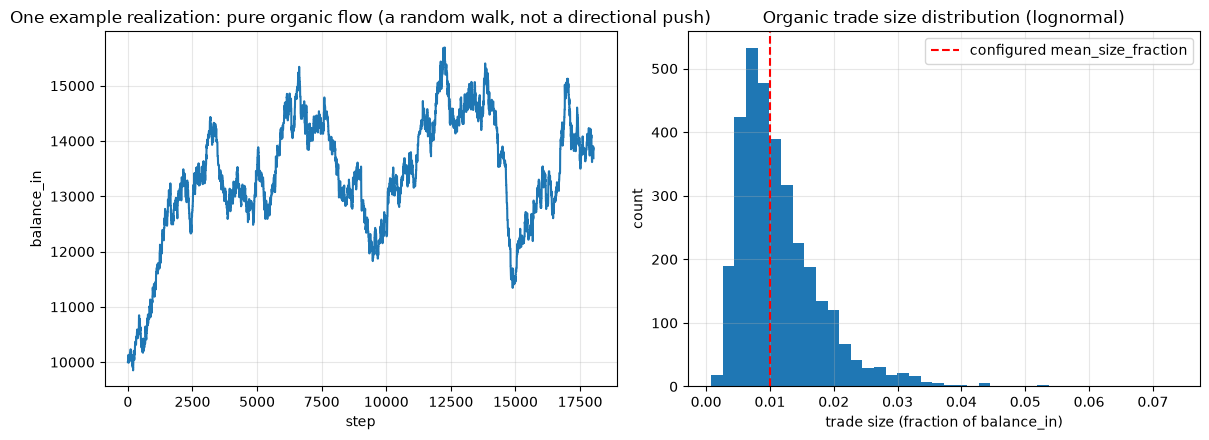

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(balance_in_path)
ax1.set_xlabel("step")
ax1.set_ylabel("balance_in")
ax1.set_title("One example realization: pure organic flow (a random walk, not a directional push)")
ax1.grid(alpha=0.3)

ax2.hist(size_fractions, bins=40)
ax2.axvline(config.mean_size_fraction, color="red", linestyle="--", label="configured mean_size_fraction")
ax2.set_xlabel("trade size (fraction of balance_in)")
ax2.set_ylabel("count")
ax2.set_title("Organic trade size distribution (lognormal)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

1. Trades arrive about as often as configured.
2. Direction is genuinely unbiased — pure background noise, not a hidden push in either
   direction (that push is the *other* kind of flow, coming up next).
3. Trade sizes match the shape we configured, and the safety cap held every time.

**Where this fits in the bigger picture:** this notebook is the "boring" half of market
activity — it doesn't correct anything, it's just noise the pool has to sit through. It's
necessary to model realistically because it's part of what the mechanism has to handle
without breaking, but it's not what proves the mechanism *works*. That's next.

Next: `03_endogenous_flow.ipynb` adds the trading that actually matters — the corrective
trades that pull the pool back toward its target. It also documents a real mistake we
found and fixed while building it, on purpose, as proof this was actually checked
carefully rather than assumed correct.